In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\tickets_clean.csv")

In [3]:
# Exploring the Data
df.head()

,ticket_id,created_date,resolved_date,category,sub_category,priority,status,subject,description,resolution,product_service,department,satisfaction_rating,time_to_resolution_hours,text_length
0,TKT-10001,2025-05-09 00:00,2025-05-09 02:12,Access/Permissions,Account Lockout,Critical,Resolved,Account locked after password change,"hi there, changed my password yesterday and no...",Account lockout was caused by mobile devices t...,Azure AD,Logistics,4.0,2.2,296
1,TKT-10002,2023-09-13 00:00,2023-09-13 07:48,Security,Malware,Critical,Closed,USB drive triggered security alert,plugged in a usb drive i got at a conference a...,USB contained autorun malware that was caught ...,Palo Alto Cortex,Customer Support,3.0,7.8,245
2,TKT-10003,2025-01-28 00:00,2025-01-28 03:12,Hardware,Desktop,Critical,Closed,Need more RAM — computer too slow with current...,my macbook pro m3 only has 8gb ram and i regul...,Approved RAM upgrade request. Installed additi...,MacBook Pro M3,Product,3.0,3.2,323
3,TKT-10004,2024-10-08 00:00,NaN,Cloud/Infrastructure,VM,Critical,Open,Need to resize VM — running out of resources,our staging vm needs to be upgraded — currentl...,NaN,Azure Blob Storage,Human Resources,NaN,NaN,264
4,TKT-10005,2025-01-11 00:00,2025-01-12 19:06,Hardware,Desktop,Low,Closed,Need more RAM — computer too slow with current...,my dell precision 5570 only has 8gb ram and i ...,Approved RAM upgrade request. Installed additi...,Dell Precision 5570,Customer Support,3.0,43.1,280


In [4]:
# Check Missing Values
Missings = df.isna().sum()
print(f"The Dataset has Missing Values at each row\n{Missings}")

The Dataset has Missing Values at each row
ticket_id                      0
created_date                   0
resolved_date               2494
category                       0
sub_category                   0
priority                       0
status                         0
subject                        0
description                    0
resolution                  2494
product_service                0
department                     0
satisfaction_rating         2494
time_to_resolution_hours    2494
text_length                    0
dtype: int64


In [5]:
# Convert to datetime
df['created_date'] = pd.to_datetime(df['created_date'])
# Extract useful tabular features from the timestamp
df['created_dayofweek'] = df['created_date'].dt.dayofweek
df['is_weekend'] = df['created_dayofweek'].isin([4, 5]).astype(int) 


In [6]:
df["created_date"] = pd.to_datetime(df["created_date"])
# Converting some Categorical Variables to categorical data type
df["category"] = df["category"].astype("category")
df["sub_category"] = df["sub_category"].astype("category")
df["priority"] = df["priority"].astype("category")
df["status"] = df["status"].astype("category")
# Converting created_hour and created_dayofweek to int64 instead of int32
df["created_dayofweek"] = df["created_dayofweek"].astype("int64")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ticket_id                 9980 non-null   object        
 1   created_date              9980 non-null   datetime64[ns]
 2   resolved_date             7486 non-null   object        
 3   category                  9980 non-null   category      
 4   sub_category              9980 non-null   category      
 5   priority                  9980 non-null   category      
 6   status                    9980 non-null   category      
 7   subject                   9980 non-null   object        
 8   description               9980 non-null   object        
 9   resolution                7486 non-null   object        
 10  product_service           9980 non-null   object        
 11  department                9980 non-null   object        
 12  satisfaction_rating 

In [ ]:
# Drop the the priority variable as it is our Target Variable
df = df.dropna(subset=['priority'])

# 2. Define your target variable (y)
y = df['priority']

# Drop the  the leaky "future" columns from your feature matrix (X) ,Dropping also Ticket_ID as it will not add any predictive power
columns_to_drop = [
    'time_to_resolution_hours', 
    'resolved_date', 
    'resolution', 
    'satisfaction_rating',
    'ticket_id'
]
X = df.drop(columns=columns_to_drop)

print(f"Dataset size after cleaning: {X.shape}")

Dataset size after cleaning: (9980, 12)


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   created_date       9980 non-null   datetime64[ns]
 1   category           9980 non-null   category      
 2   sub_category       9980 non-null   category      
 3   priority           9980 non-null   category      
 4   status             9980 non-null   category      
 5   subject            9980 non-null   object        
 6   description        9980 non-null   object        
 7   product_service    9980 non-null   object        
 8   department         9980 non-null   object        
 9   text_length        9980 non-null   int64         
 10  created_dayofweek  9980 non-null   int64         
 11  is_weekend         9980 non-null   int64         
dtypes: category(4), datetime64[ns](1), int64(3), object(4)
memory usage: 665.0+ KB


In [10]:
X.head()


,created_date,category,sub_category,priority,status,subject,description,product_service,department,text_length,created_dayofweek,is_weekend
0,2025-05-09,Access/Permissions,Account Lockout,Critical,Resolved,Account locked after password change,"hi there, changed my password yesterday and no...",Azure AD,Logistics,296,4,1
1,2023-09-13,Security,Malware,Critical,Closed,USB drive triggered security alert,plugged in a usb drive i got at a conference a...,Palo Alto Cortex,Customer Support,245,2,0
2,2025-01-28,Hardware,Desktop,Critical,Closed,Need more RAM — computer too slow with current...,my macbook pro m3 only has 8gb ram and i regul...,MacBook Pro M3,Product,323,1,0
3,2024-10-08,Cloud/Infrastructure,VM,Critical,Open,Need to resize VM — running out of resources,our staging vm needs to be upgraded — currentl...,Azure Blob Storage,Human Resources,264,1,0
4,2025-01-11,Hardware,Desktop,Low,Closed,Need more RAM — computer too slow with current...,my dell precision 5570 only has 8gb ram and i ...,Dell Precision 5570,Customer Support,280,5,1


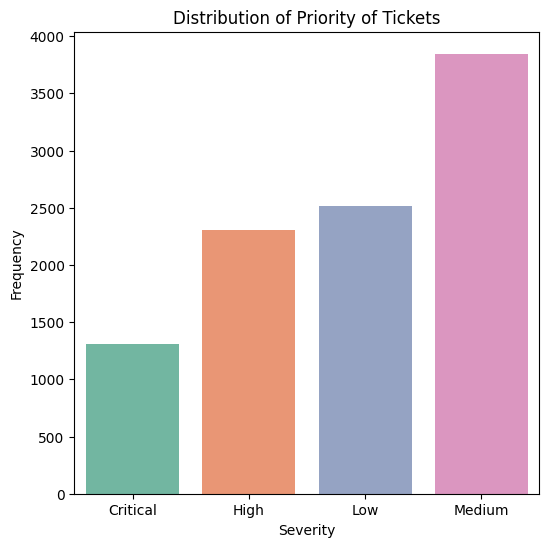

In [11]:
# Visualizing the Distribuition of our Target Variable (time_to_resolution_hours)
plt.figure(figsize=(6,6))
sns.countplot(data=df , x=df["priority"] , palette="Set2" , hue= df["priority"])
plt.title("Distribution of Priority of Tickets")
plt.xlabel("Severity")
plt.ylabel("Frequency")
plt.show()

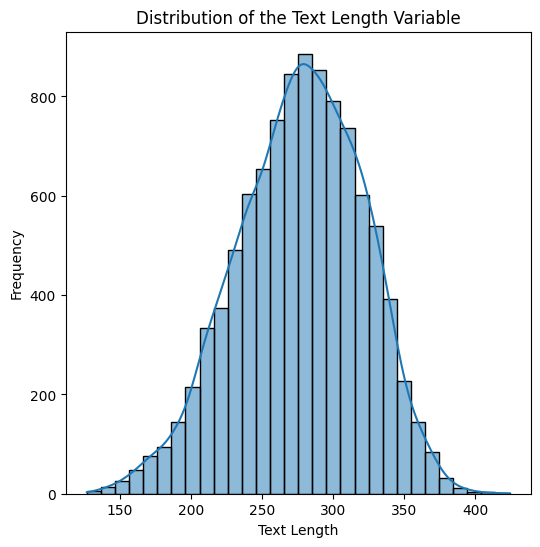

In [12]:
# Numerical Variable Distribution in my Feature Matrix (text_length)
plt.figure(figsize=(6,6))
sns.histplot(data= X["text_length"] , bins= 30 , kde= True)
plt.title("Distribution of the Text Length Variable")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


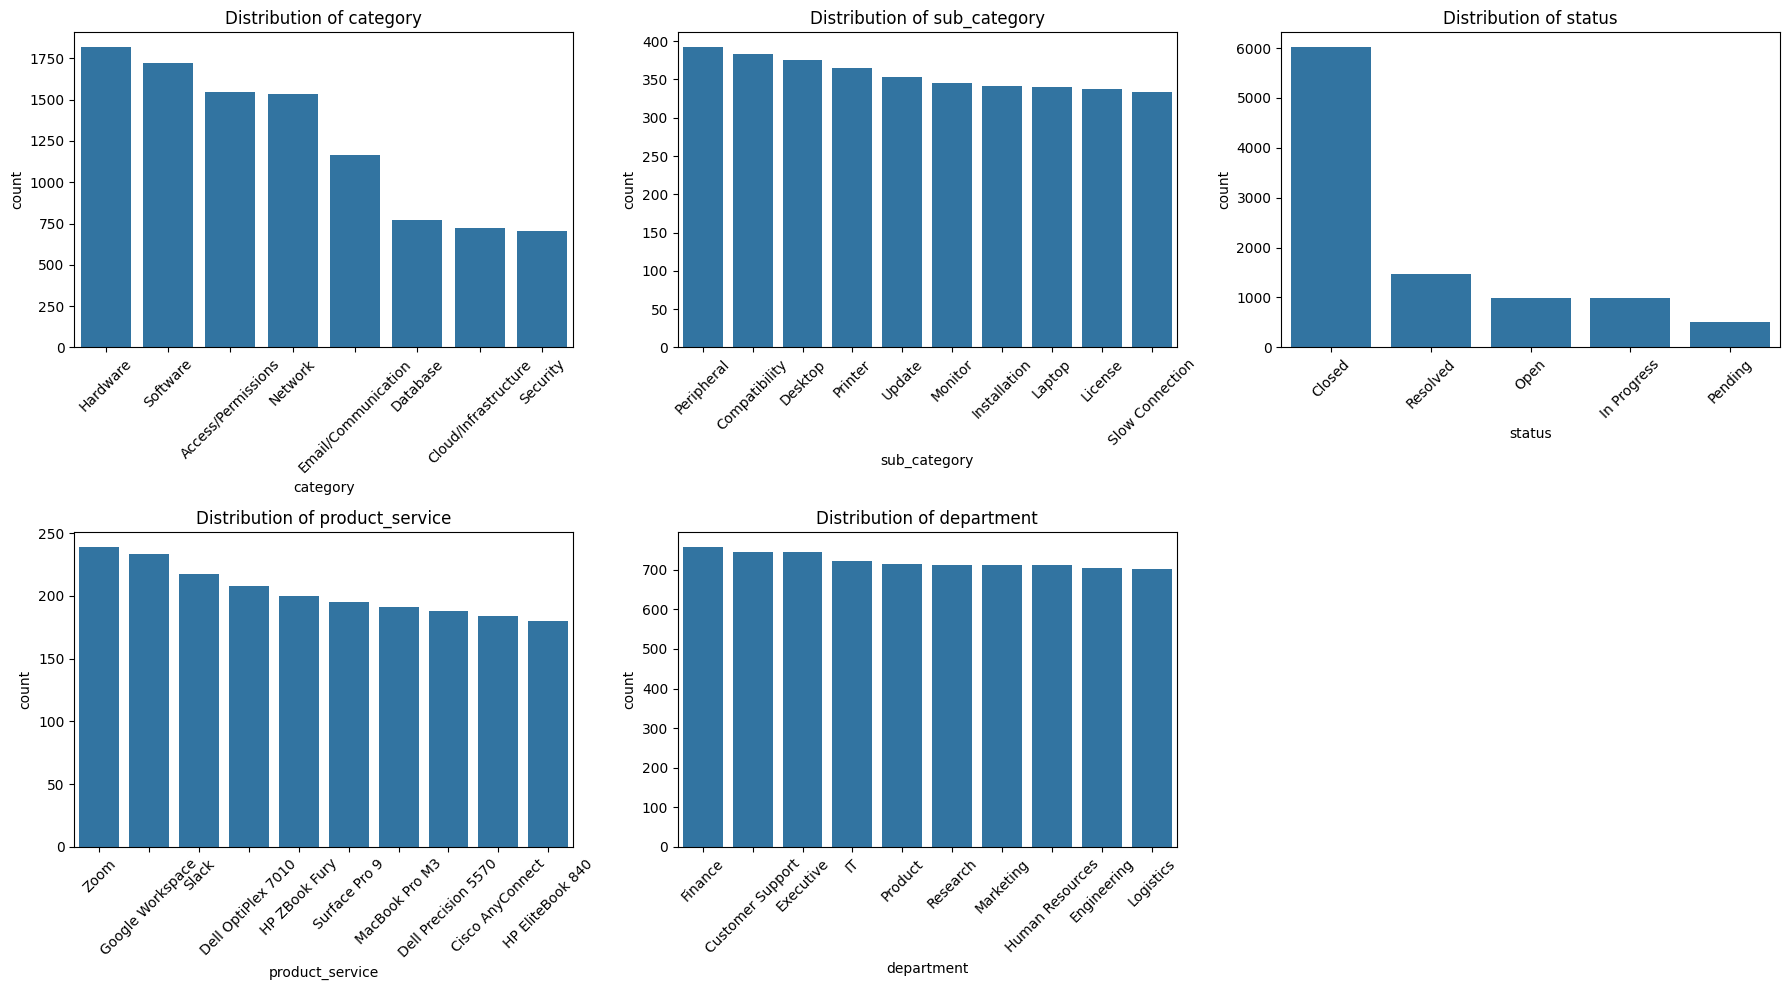

In [13]:
# Categorical Variables Distribution 
categorical_cols = [
    "category",
    "sub_category",
    "status",
    "product_service",
    "department"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, ax in zip(categorical_cols, axes.flat):
    top_cats = X[col].value_counts().nlargest(10).index
    sns.countplot(data=X, x=col, ax=ax , order= top_cats)
    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis="x", rotation=45)

plt.delaxes(axes.flat[-1])
plt.tight_layout()
plt.show()

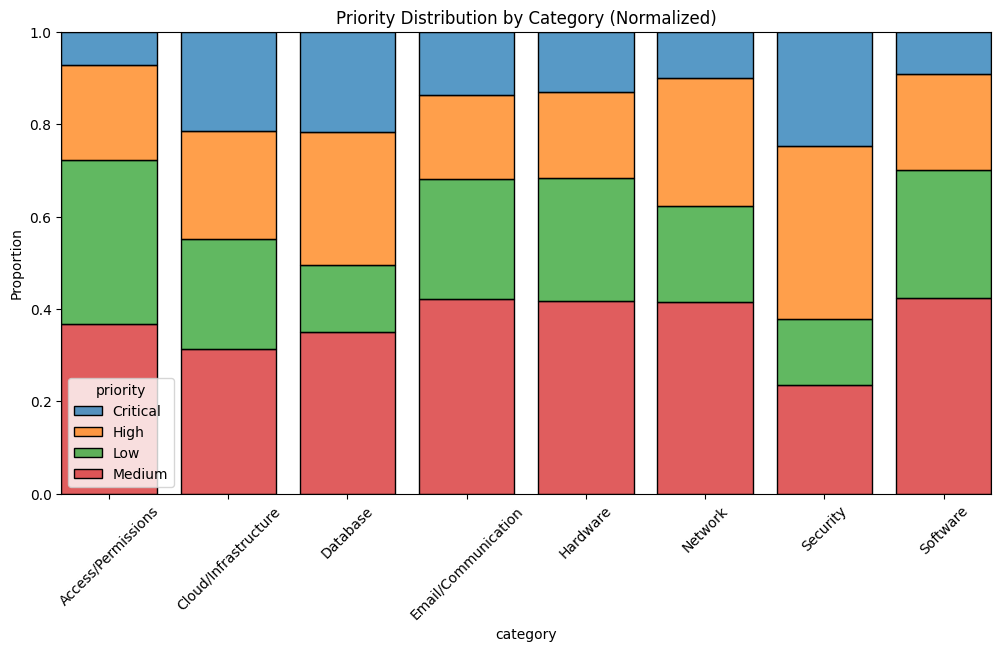

In [14]:
# Proportion of Priority levels across different Categories
plt.figure(figsize=(12, 6))
sns.histplot(data=X, x='category', hue='priority', multiple='fill', shrink=0.8)
plt.title('Priority Distribution by Category (Normalized)')
plt.xticks(rotation=45)
plt.ylabel('Proportion')
plt.show()

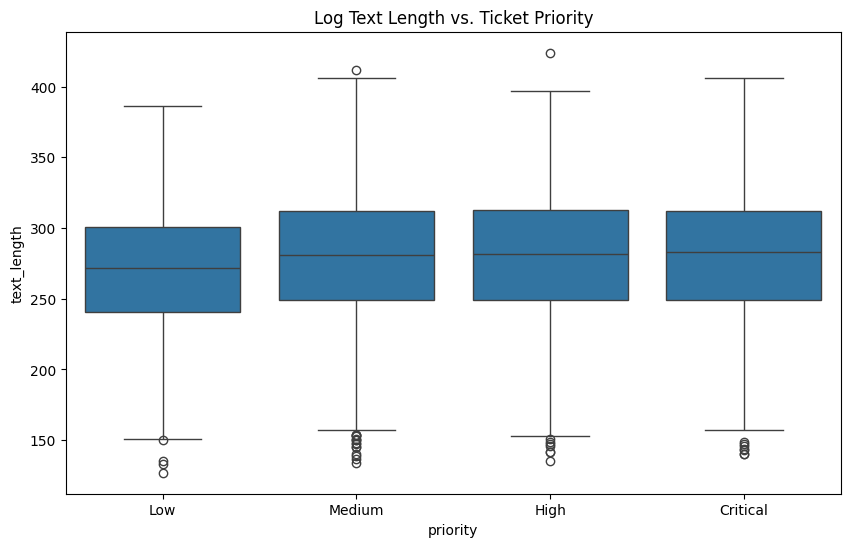

In [15]:
# Text Length vs Priority
plt.figure(figsize=(10, 6))
sns.boxplot(data=X, x='priority', y='text_length', order=['Low', 'Medium', 'High', 'Critical'])
plt.title('Log Text Length vs. Ticket Priority')
plt.show()

In [16]:
# Temporary mapping for EDA correlation
priority_mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}

# Apply to a temporary EDA dataframe
df_eda = df.copy()
df_eda['priority_numeric'] = df_eda['priority'].map(priority_mapping)

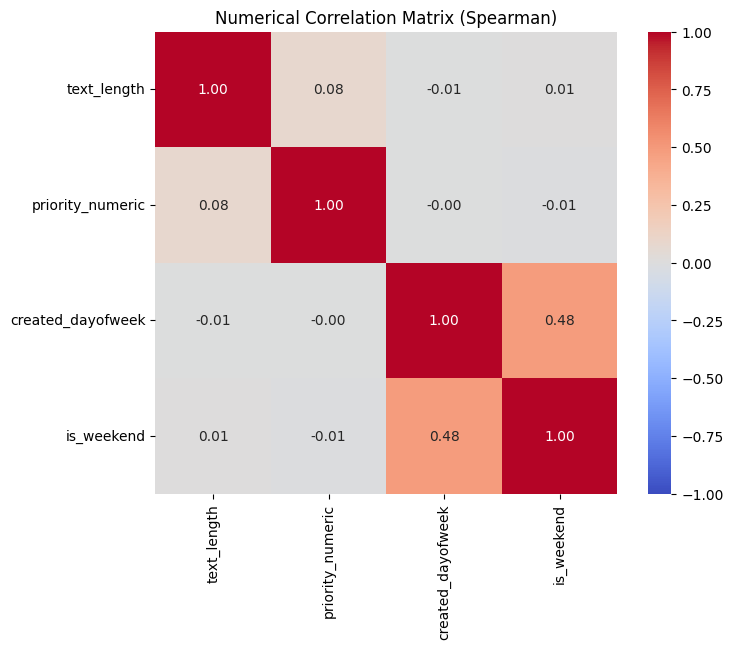

In [17]:
# Add any other numerical columns you have (e.g., historical rolling metrics if engineered)
numerical_cols = ['text_length', 'priority_numeric' , 'created_dayofweek' , 'is_weekend'] 

# Calculate Spearman correlation
num_corr_matrix = df_eda[numerical_cols].corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(num_corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Numerical Correlation Matrix (Spearman)")
plt.show()

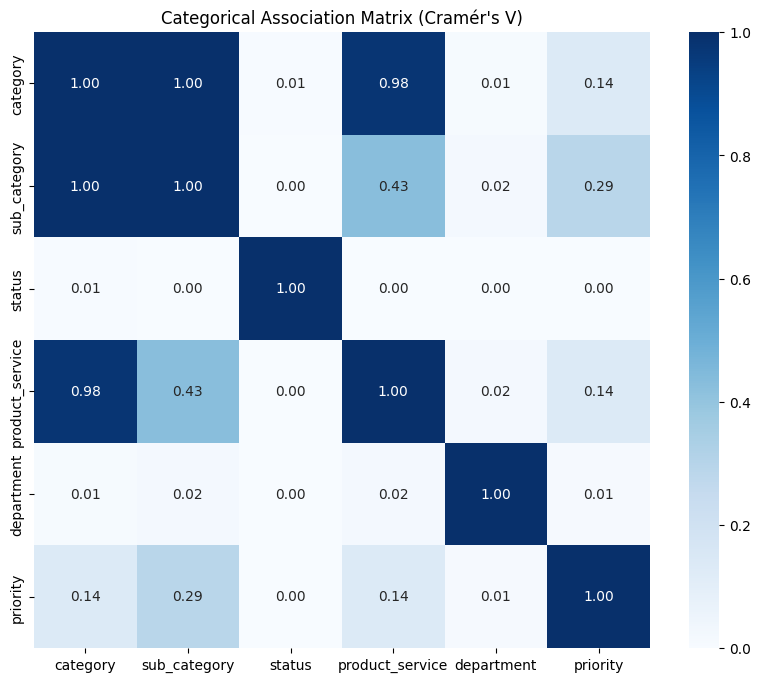

In [18]:
from scipy.stats import chi2_contingency

# 1. Define the Cramér's V function with bias correction
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Bias correction for accurate estimates
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    # Handle edge case where denominator might be 0
    min_dim = min((kcorr-1), (rcorr-1))
    if min_dim == 0:
        return 0.0
    return np.sqrt(phi2corr / min_dim)

# 2. Select categorical columns (including the string version of priority)
categorical_cols = [
    "category", "sub_category", "status", 
    "product_service", "department", "priority"
]

# 3. Compute the matrix
cramer_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Convert object matrix to float for Seaborn
cramer_matrix = cramer_matrix.astype(float)

# 4. Plot the Categorical Association Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cramer_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, fmt=".2f", square=True)
plt.title("Categorical Association Matrix (Cramér's V)")
plt.show()